In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import pandas as pd
import argparse
from matplotlib import cm



In [4]:

exp_dir = "/Users/liyingnceas/GitHub/Deep-hurdle-population-model-exp/experiments/default_experiment/version_12"
binary_path = os.path.join(exp_dir, "binary_results.npz")
binary_data = np.load(binary_path)["data"]

In [5]:
binary_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(17331, 700), dtype=float32)

In [ ]:
# 1) split into GT and Pred
n = binary_data.shape[1] // 2
assert binary_data.shape[1] == 2 * n, "Expected an even number of columns (GT + Pred)."
gt = binary_data[:, :n]
pred = binary_data[:, n:]

# 2) get feature (species) names from count_predictions
#    If count_predictions has non-species cols (e.g., longitude/latitude),
#    keep only the first n names or filter as needed.
if isinstance(count_predictions, pd.DataFrame):
    all_cols = list(count_predictions.columns)
else:
    all_cols = list(count_predictions)

feature_names = all_cols[:n]
assert len(feature_names) == n, "Number of provided feature names must match n."

# 3) build DataFrames with clear names
gt_df   = pd.DataFrame(gt,   columns=feature_names).astype(np.float32)
pred_df = pd.DataFrame(pred, columns=feature_names).astype(np.float32)

# optional: one wide DF with suffixes
wide_df = pd.concat(
    [gt_df.add_suffix("_gt"), pred_df.add_suffix("_pred")],
    axis=1
)


In [17]:
count_predictions = pd.read_csv("multiplied_result.csv")
count_predictions 
# 1) split into GT and Pred
n = binary_data.shape[1] // 2
assert binary_data.shape[1] == 2 * n, "Expected an even number of columns (GT + Pred)."
gt = binary_data[:, :n]
pred = binary_data[:, n:]

# 2) get label (species) names from count_predictions
#    If count_predictions has non-species cols (e.g., longitude/latitude),
#    keep only the first n names or filter as needed.
if isinstance(count_predictions, pd.DataFrame):
    all_cols = list(count_predictions.columns[2:])
else:
    all_cols = list(count_predictions[2:])

label_names = all_cols[:n]
assert len(label_names) == n, "Number of provided feature names must match n."

# 3) build DataFrames with clear names
gt_df   = pd.DataFrame(gt,   columns=label_names).astype(np.float32)
pred_df = pd.DataFrame(pred, columns=label_names).astype(np.float32)
gt_df


,Acadian Flycatcher,Alder Flycatcher,Allen's Hummingbird,American Avocet,American Bittern,American Coot,American Crow,American Golden-Plover,American Goldfinch,American Kestrel,...,Yellow Warbler,Yellow-bellied Flycatcher,Yellow-bellied Sapsucker,Yellow-billed Cuckoo,Yellow-breasted Chat,Yellow-crowned Night Heron,Yellow-headed Blackbird,Yellow-rumped Warbler,Yellow-throated Vireo,Yellow-throated Warbler
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
17327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Load trait data
trait_file="AVONET2_eBird.xlsx"
traits_df = pd.read_excel(trait_file, engine='openpyxl')[['Species2', 'Primary.Lifestyle']]
traits_df = traits_df.dropna(subset=['Species2', 'Primary.Lifestyle'])


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# === Config ===

trait = "Habitat"  # or any other trait column name
trait_file = "AVONET2_eBird.xlsx"
taxonomy_file = "ebird-taxonomy.csv"


# === Step 1: Extract species feature matrix (transpose so species are rows) ===
species_gt = gt_df.copy().T  # shape: [n_species, n_samples]
species_gt.index.name = 'Species'
species_gt = species_gt.fillna(0)

species_pred = pred_df.copy().T  # shape: [n_species, n_samples]
species_pred.index.name = 'Species'
species_pred = species_pred.fillna(0)

# === Step 2: Trait mapping ===
traits_df = pd.read_excel(trait_file, engine='openpyxl')[['Species2', trait]]
traits_df = traits_df.dropna(subset=['Species2', trait])

taxonomy = pd.read_csv(taxonomy_file)
sci_to_common = dict(zip(taxonomy['scientific_name'], taxonomy['common_name']))
traits_df['Species2'] = traits_df['Species2'].map(sci_to_common)

# === Step 3: Map traits to species ===
species_to_group = dict(zip(traits_df['Species2'], traits_df[trait]))
species_gt = species_gt.reset_index()
species_gt['TraitGroup'] = species_gt['Species'].map(species_to_group)
species_gt = species_gt.dropna(subset=['TraitGroup'])
species_pred = species_pred.reset_index()
species_pred['TraitGroup'] = species_pred['Species'].map(species_to_group)
species_pred = species_pred.dropna(subset=['TraitGroup'])



          Habitat     TP     FP     FN      TN  Precision    Recall        F1  \
0          Marine  14996  35726   2884  223690   0.295651  0.838702  0.437188   
1        Woodland  30513  69862  11004  373889   0.303990  0.734952  0.430088   
2  Human Modified  18340  55843   7366  247740   0.247226  0.713452  0.367208   
3       Shrubland  26842  88493  10103  498478   0.232731  0.726539  0.352535   
4        Riverine   1533   8262    518   41680   0.156508  0.747440  0.258822   

   Accuracy  True Positives (count)  Pred Positives (count)  
0  0.860763                   17880                   50722  
1  0.833358                   41517                  100375  
2  0.808044                   25706                   74183  
3  0.841972                   36945                  115335  
4  0.831131                    2051                    9795  


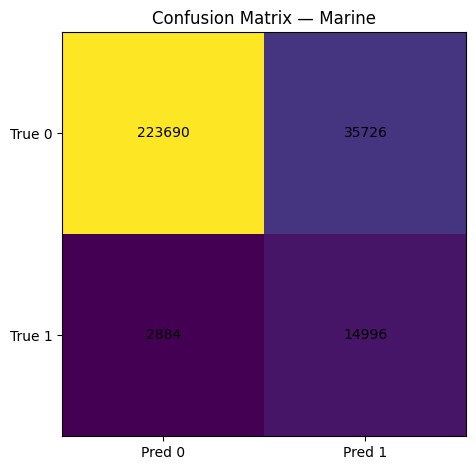

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- Prep: align by species and keep only sample columns -----
sg = species_gt.set_index('Species')
sp = species_pred.set_index('Species')

# group labels per species
groups = sg['TraitGroup']

# keep only sample columns (everything except TraitGroup)
sg_X = sg.drop(columns=['TraitGroup'])
sp_X = sp.drop(columns=['TraitGroup'])

# ensure same species and same sample columns in same order
common_species = sg_X.index.intersection(sp_X.index)
common_samples = sg_X.columns.intersection(sp_X.columns)
sg_X = sg_X.loc[common_species, common_samples]
sp_X = sp_X.loc[common_species, common_samples]
groups = groups.loc[common_species]

# ----- Helper: confusion counts and metrics -----
def confusion_counts(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tn, fp, fn, tp

def prec_rec_f1_acc(tn, fp, fn, tp):
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
    acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else np.nan
    return prec, rec, f1, acc

# ----- Main: compute confusion per habitat -----
threshold = 0.5  # change if your predictions are already 0/1
results = []
cm_by_habitat = {}

for hab, idx in groups.groupby(groups).groups.items():
    y_true = sg_X.loc[idx].to_numpy().ravel()
    y_pred = sp_X.loc[idx].to_numpy().ravel()

    # drop NaNs
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # binarize if needed
    y_true = (y_true >= threshold).astype(int)
    y_pred = (y_pred >= threshold).astype(int)

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    prec, rec, f1, acc = prec_rec_f1_acc(tn, fp, fn, tp)

    results.append({
        "Habitat": hab,
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Precision": prec, "Recall": rec, "F1": f1, "Accuracy": acc,
        "True Positives (count)": int((y_true == 1).sum()),
        "Pred Positives (count)": int((y_pred == 1).sum())
    })
    cm_by_habitat[hab] = np.array([[tn, fp],
                                   [fn, tp]], dtype=int)

cm_summary = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
print(cm_summary.head())

# ----- Example plot for one habitat -----
example_habitat = cm_summary.iloc[0]["Habitat"]  # top F1 habitat (or set manually)
cm = cm_by_habitat[example_habitat]

fig, ax = plt.subplots()
im = ax.imshow(cm)
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred 0','Pred 1'])
ax.set_yticks([0,1]); ax.set_yticklabels(['True 0','True 1'])
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center')
ax.set_title(f'Confusion Matrix — {example_habitat}')
plt.tight_layout()
plt.show()


In [19]:
species_gt

,Species,0,1,2,3,4,5,6,7,8,...,17322,17323,17324,17325,17326,17327,17328,17329,17330,TraitGroup
0,Acadian Flycatcher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Forest
1,Alder Flycatcher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Shrubland
2,Allen's Hummingbird,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Shrubland
3,American Avocet,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Wetland
4,American Bittern,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Wetland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,Yellow-crowned Night Heron,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Coastal
346,Yellow-headed Blackbird,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Wetland
347,Yellow-rumped Warbler,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,Forest
348,Yellow-throated Vireo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Forest


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def confusion_by_group(species_gt, species_pred, group_col="TraitGroup", threshold=0.5):
    """
    Compute per-group confusion matrices by flattening all species x samples
    that belong to each group (micro-averaging within group).

    Parameters
    ----------
    species_gt : pd.DataFrame
        Rows: species, Columns: samples, plus ['Species', group_col]
    species_pred : pd.DataFrame
        Same shape/structure as species_gt
    group_col : str
        Column name that holds the group label (e.g., 'TraitGroup' == Habitat)
    threshold : float
        Threshold to binarize GT and predictions if they are probabilities

    Returns
    -------
    cm_summary : pd.DataFrame
        Per-group counts and metrics (TN, FP, FN, TP, Precision, Recall, F1, Acc, etc.)
    cm_dict : dict[str, np.ndarray]
        {group: 2x2 numpy array [[TN, FP],[FN, TP]]}
    """
    # --- align by species and shared sample columns ---
    sg = species_gt.set_index('Species')
    sp = species_pred.set_index('Species')

    # group labels from GT table
    groups = sg[group_col]

    # only sample columns (drop the group col)
    sg_X = sg.drop(columns=[group_col])
    sp_X = sp.drop(columns=[group_col])

    # intersect on species and sample columns
    common_species = sg_X.index.intersection(sp_X.index)
    common_cols = sg_X.columns.intersection(sp_X.columns)
    sg_X = sg_X.loc[common_species, common_cols]
    sp_X = sp_X.loc[common_species, common_cols]
    groups = groups.loc[common_species]

    # helpers
    def counts(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tn, fp, fn, tp

    def metrics(tn, fp, fn, tp):
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = (2*prec*rec/(prec+rec)) if (prec + rec) else 0.0
        acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else np.nan
        tnr  = tn / (tn + fp) if (tn + fp) else np.nan  # specificity
        fpr  = fp / (fp + tn) if (fp + tn) else np.nan
        fnr  = fn / (fn + tp) if (fn + tp) else np.nan
        return prec, rec, f1, acc, tnr, fpr, fnr

    cm_rows = []
    cm_dict = {}

    for grp, idx in groups.groupby(groups).groups.items():
        y_true = sg_X.loc[idx].to_numpy().ravel()
        y_pred = sp_X.loc[idx].to_numpy().ravel()

        # drop NaNs
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        y_true = y_true[mask]
        y_pred = y_pred[mask]

        # binarize (set threshold=0 if data already 0/1)
        y_true = (y_true >= threshold).astype(int)
        y_pred = (y_pred >= threshold).astype(int)

        tn, fp, fn, tp = counts(y_true, y_pred)
        prec, rec, f1, acc, tnr, fpr, fnr = metrics(tn, fp, fn, tp)

        cm_dict[grp] = np.array([[tn, fp],
                                 [fn, tp]], dtype=int)
        cm_rows.append({
            "Habitat": grp,
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            "Support_true_positives": int((y_true == 1).sum()),
            "Support_samples": int(y_true.size),
            "Precision": prec, "Recall": rec, "F1": f1, "Accuracy": acc,
            "Specificity": tnr, "FPR": fpr, "FNR": fnr
        })

    cm_summary = pd.DataFrame(cm_rows).sort_values("F1", ascending=False).reset_index(drop=True)
    return cm_summary, cm_dict

# ---- run it ----
cm_summary, cm_dict = confusion_by_group(species_gt, species_pred, group_col="TraitGroup", threshold=0.5)
cm_summary


,Habitat,TN,FP,FN,TP,Support_true_positives,Support_samples,Precision,Recall,F1,Accuracy,Specificity,FPR,FNR
0,Marine,223690,35726,2884,14996,17880,277296,0.295651,0.838702,0.437188,0.860763,0.862283,0.137717,0.161298
1,Woodland,373889,69862,11004,30513,41517,485268,0.303990,0.734952,0.430088,0.833358,0.842565,0.157435,0.265048
2,Human Modified,247740,55843,7366,18340,25706,329289,0.247226,0.713452,0.367208,0.808044,0.816054,0.183946,0.286548
3,Shrubland,498478,88493,10103,26842,36945,623916,0.232731,0.726539,0.352535,0.841972,0.849238,0.150762,0.273461
4,Riverine,41680,8262,518,1533,2051,51993,0.156508,0.747440,0.258822,0.831131,0.834568,0.165432,0.252560
5,Coastal,256704,45503,1981,7770,9751,311958,0.145852,0.796841,0.246573,0.847787,0.849431,0.150569,0.203159
6,Forest,1447011,221813,13302,33643,46945,1715769,0.131698,0.716647,0.222506,0.862968,0.867084,0.132916,0.283353
7,Wetland,1387399,231850,11696,32831,44527,1663776,0.124040,0.737328,0.212355,0.853619,0.856816,0.143184,0.262672
8,Grassland,518281,48464,1732,3446,5178,571923,0.066384,0.665508,0.120726,0.912233,0.914487,0.085513,0.334492


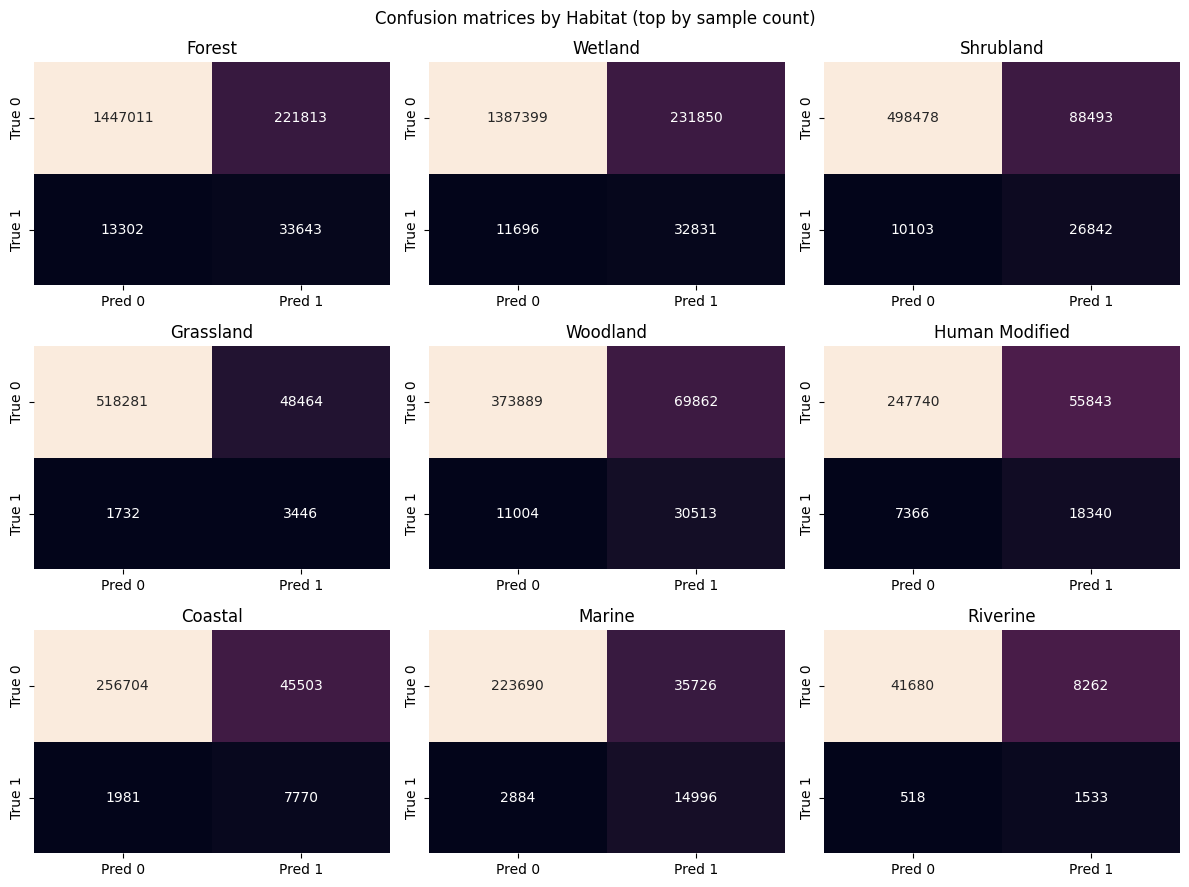

In [29]:
import math
import seaborn as sns

top = cm_summary.sort_values("Support_samples", ascending=False).head(9)["Habitat"].tolist()
n = len(top)
cols = 3
rows = math.ceil(n/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = np.array(axes).reshape(rows, cols)

for ax, hab in zip(axes.ravel(), top):
    cm = cm_dict[hab]
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax,
                xticklabels=["Pred 0","Pred 1"],
                yticklabels=["True 0","True 1"])
    ax.set_title(hab)

# hide unused axes
for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.suptitle("Confusion matrices by Habitat (top by sample count)")
plt.tight_layout()
plt.show()


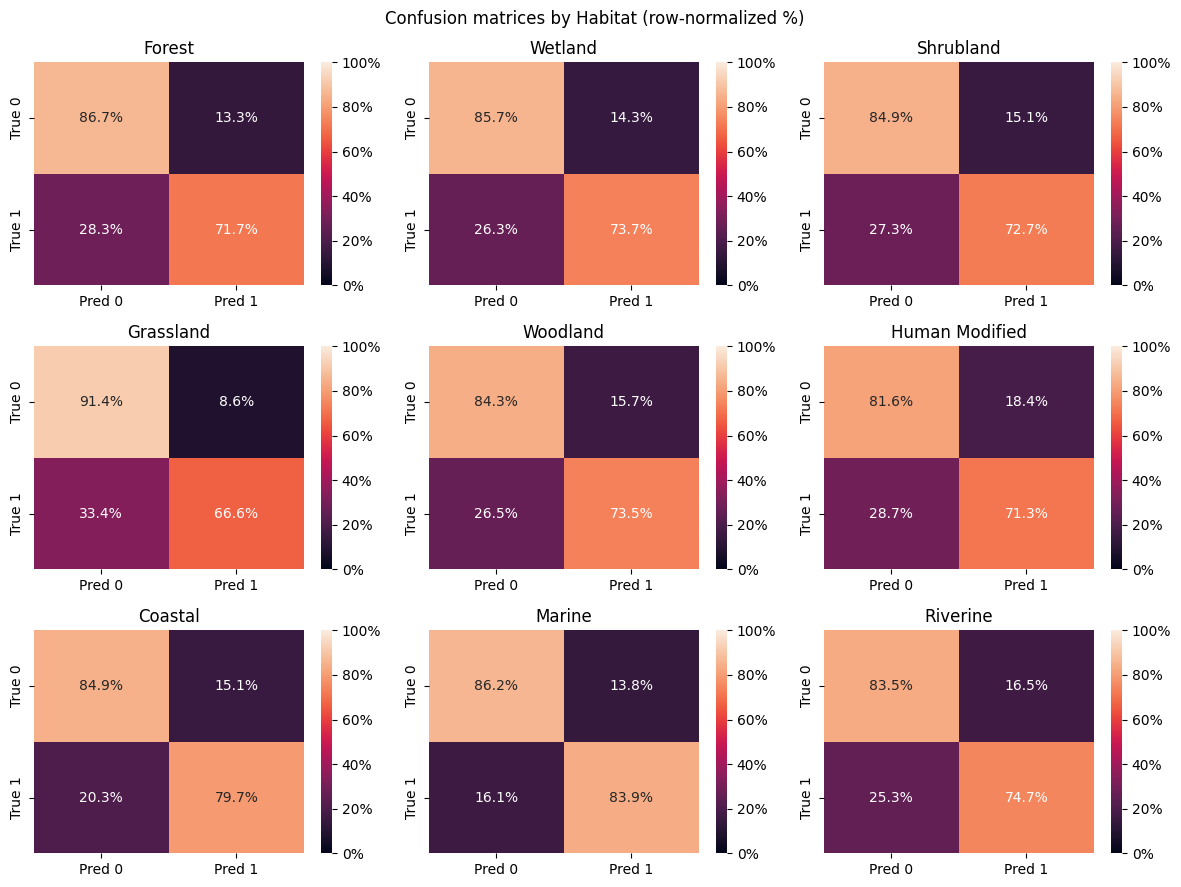

In [30]:
import numpy as np
from matplotlib.ticker import PercentFormatter

top = cm_summary.sort_values("Support_samples", ascending=False).head(9)["Habitat"].tolist()
n = len(top)
cols = 3
rows = math.ceil(n/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = np.array(axes).reshape(rows, cols)

for ax, hab in zip(axes.ravel(), top):
    cm = cm_dict[hab].astype(float)                     # [[TN, FP],[FN, TP]]

    # --- ROW normalization (True 0 row, True 1 row) ---
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1                         # avoid divide-by-zero
    cm_pct = cm / row_sums                               # values in [0,1]

    # Pretty percent annotations like "83.3%"
    annot = np.array([[f"{v:.1%}" for v in row] for row in cm_pct])

    sns.heatmap(
        cm_pct, annot=annot, fmt="", cbar=True, ax=ax,
        xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
        vmin=0, vmax=1, cbar_kws={"format": PercentFormatter(xmax=1)}
    )
    ax.set_title(hab)

# hide unused axes
for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.suptitle("Confusion matrices by Habitat (row-normalized %)")
plt.tight_layout()
plt.show()


In [32]:
import os

out_pdf = "confusion_matrices_by_habitat_row_norm.pdf"

# after plt.tight_layout()
fig.savefig(out_pdf, format="pdf", dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {out_pdf}")


Saved: confusion_matrices_by_habitat_row_norm.pdf


Saved grid PNG: figs/confusion_by_habitat_row_norm_orgreen1.png
Saved grid PDF: figs/confusion_by_habitat_row_norm_orgreen1.pdf


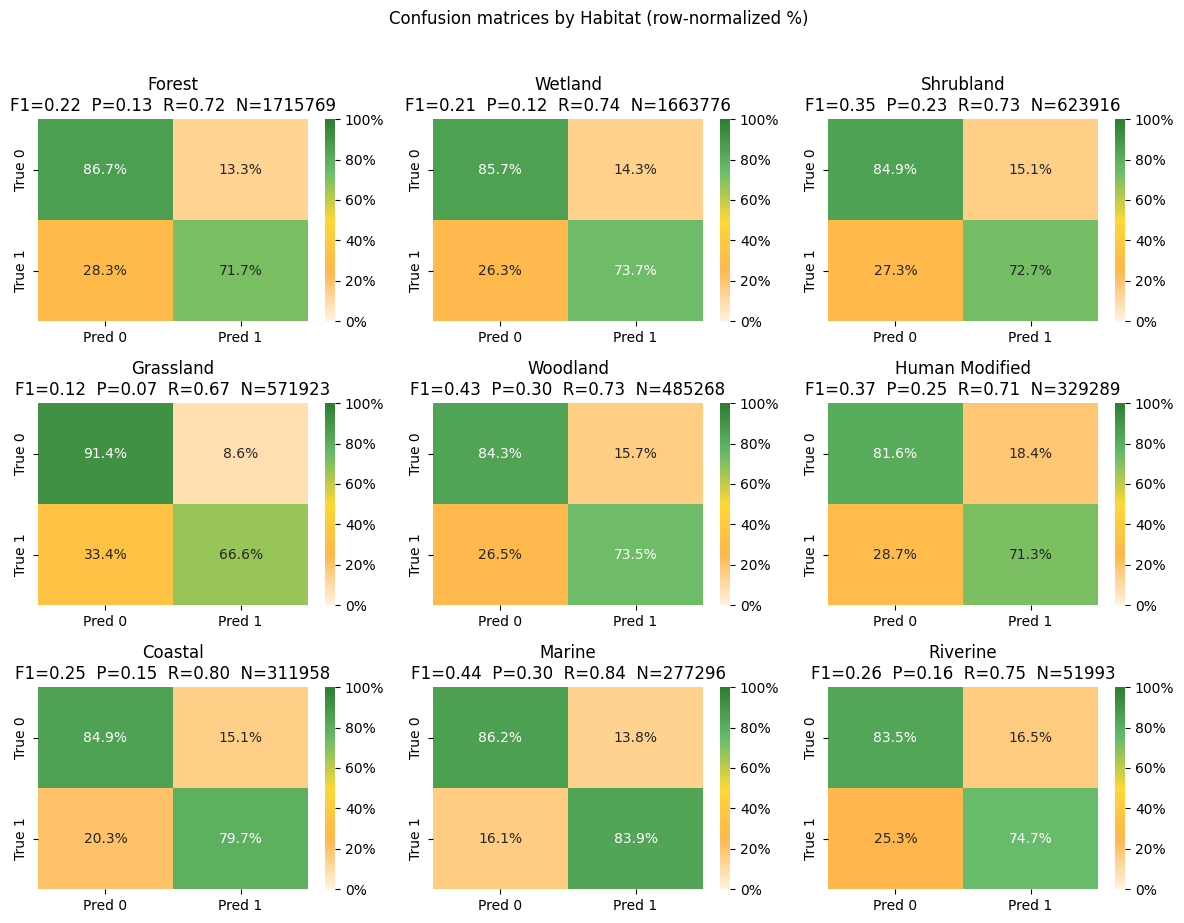

In [ ]:
# === Strong-contrast confusion-matrix heatmaps (orange -> dark red) ===
# Prereqs: cm_summary (DataFrame) and cm_dict ({habitat: 2x2 numpy array})
# built earlier via your confusion-by-habitat code.

import os, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from matplotlib.backends.backend_pdf import PdfPages
# --- Custom high-contrast colormap: different color options pick one you like ---

red_to_blue = LinearSegmentedColormap.from_list(
    "red_to_blue",
    [
        "#FDE0DD",  # very light red
        "#FDA0A1",  # light red
        "#FB6A4A",  # medium red
        "#9ECAE1",  # light blue
        "#4292C6",  # medium blue
        "#08519C",  # dark blue
    ]
)
green_to_orange = LinearSegmentedColormap.from_list(
    "green_to_orange",
    [
        "#E8F5E9",  # very light green
        "#A5D6A7",  # light/medium green
        "#66BB6A",  # medium green
        "#FDD835",  # warm yellow
        "#FB8C00",  # orange
        "#E65100",  # dark orange
    ]
)
red_to_green = LinearSegmentedColormap.from_list(
    "red_to_green",
    [
        "#FDE0DD",  # very light red (low)
        "#FC9272",  # salmon
        "#FEE08B",  # warm yellow mid
        "#78C679",  # medium green
        "#31A354",  # strong green
        "#0B7D2A",  # dark green (high)
    ]
)
yellow_to_darkgreen = LinearSegmentedColormap.from_list(
    "yellow_to_darkgreen",
    ["#FFFACD", "#F1F7A1", "#A1D76A", "#31A354"]  # pale yellow -> deep green
)
# --- Custom high-contrast colormap: orange -> dark red ---
orange_to_darkred = LinearSegmentedColormap.from_list(
    "orange_to_darkred",
    ["#FFA500", "#FF8C00", "#D62728", "#8B0000"]  # orange → dark red
)
orange_to_green = LinearSegmentedColormap.from_list(
    "orange_to_green",
    [
        "#FFF3E0",  # very light orange (low)
        "#FFB74D",  # orange
        "#FDD835",  # warm yellow mid
        "#66BB6A",  # medium green
        "#2E7D32",  # dark green (high)
    ]
)
# --- Select habitats to plot (top 9 by sample count) ---
top = cm_summary.sort_values("Support_samples", ascending=False).head(12)["Habitat"].tolist()
n = len(top)
cols = 3
rows = math.ceil(n / cols)

# --- Make figure grid ---
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = np.atleast_2d(axes).reshape(rows, cols)

for ax, hab in zip(axes.ravel(), top):
    cm = cm_dict[hab].astype(float)  # [[TN, FP],[FN, TP]]

    # Row-normalize: each true class row sums to 1.0
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1     # avoid divide-by-zero if a row is empty
    cm_pct = cm / row_sums

    # Pretty percentage annotations
    annot = np.array([[f"{v:.1%}" for v in row] for row in cm_pct])

    sns.heatmap(
        cm_pct, annot=annot, fmt="", cbar=True, ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        vmin=0, vmax=1,
        cmap=orange_to_green,
        cbar_kws={"format": PercentFormatter(xmax=1)}
    )
    # Optional: include metrics in the title
    r = cm_summary.loc[cm_summary["Habitat"] == hab].iloc[0]
    ax.set_title(f"{hab}\nF1={r['F1']:.2f}  P={r['Precision']:.2f}  R={r['Recall']:.2f}  N={int(r['Support_samples'])}")

# Hide any unused axes
for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.suptitle("Confusion matrices by Habitat (row-normalized %)", y=1.02)
plt.tight_layout()

# --- Optional saves ---
os.makedirs("figs", exist_ok=True)
grid_png = "figs/confusion_by_habitat_row_norm_orgreen1.png"
grid_pdf = "figs/confusion_by_habitat_row_norm_orgreen1.pdf"
fig.savefig(grid_png, dpi=300, bbox_inches="tight")
fig.savefig(grid_pdf, dpi=300, bbox_inches="tight")
print(f"Saved grid PNG: {grid_png}")
print(f"Saved grid PDF: {grid_pdf}")

# --- Optional: multi-page PDF (one habitat per page)
